# Assignment 2 - Image Classification and CNN

### Tevyn Vergara | 46421201 | Electrical & Biomedical Engineer

DISCLAIMER: Google Gemini 3 was used for this assignment for:
1. Layout tips (all questions)
2. Syntax checking (all questions)
3. Trouble shooting and debugging
4. Functionality tips and suggestions (all questions)
5. Tips and explanation for key functions/theories and purposes
6. Re-organizing to look more modular and readable

References:
1. Google. (2026, March 17). Methods of providing alterative text for accessibility on websites. [Generative AI chat]. Gemini 3. https://gemini.google.com/


## Standard Imports for Assignment 2 ##

Please run this before executing any other cell

In [1]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import tensorflow as tf
import skimage
import sys
print('numpy', np.__version__)
print('matplotlib', plt.matplotlib.__version__)
print('tensorflow', tf.__version__)
print('skimage', skimage.__version__)

numpy 2.4.4
matplotlib 3.10.8
tensorflow 2.21.0
skimage 0.26.0


## NOTE: Code was ran locally as I have a dedicated GPU ##

## Question "0" - CIFAR-10 Dataset ##

Here, I'm attempting to load the images. The formatting is currently:

- Labels in batches.meta [0-9] with their respective image classes:
    0: Aeroplane
    1: Automobile
    2: Bird
    3: Cat
    4: Deer
    5: Dog
    6: Frog
    7: Horse
    8: Ship
    9: Truck

- 3072 features of flattened information --> 32 x 32 pixel images with 3 RGB channels 

- 50,000 training images split into x5 data_batch_x files (5 in total). Format: shape(10,000, 3072). So 10,000 images per batch of 3072 flattened information

To format for CNN training:
1. Use unpickle() from source: https://www.cs.toronto.edu/~kriz/cifar.html. This returns a batch dictionary of the 10,000 images, their labels, and each of their single channel information of (32x32 | 3 RGB). Their is also metadata for the batch such as the image and batch file names (Not needed for project)

2. Unload image class labels from batches.meta (0-9) and convert their byte strings to normal text for readibility. Store in meta.

3. Unload and also combine the 5 batches of training data from data_batch_x where x: [0,5]. Assuming that all the images have the same format of 
(32x32 |3 RGB), append all imagee (with their data) and their respective labels to a dictionary of arrays that contain:
    - Image data (batch[b"data"])
    - Image labels (batch[b"data"])
    - Metadata (filenames, image names) but unused


To ensure that testing data was loaded correctly, loop through the whole "batch" dataset and load the first image of each class. Display it and its respective label.



C:\Users\tevyn\AppData\Local\Temp\ipykernel_38720\4122671099.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(fo, encoding="bytes")


X_train shape: (50000, 3072)
y_train shape: (50000,)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)
Label names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


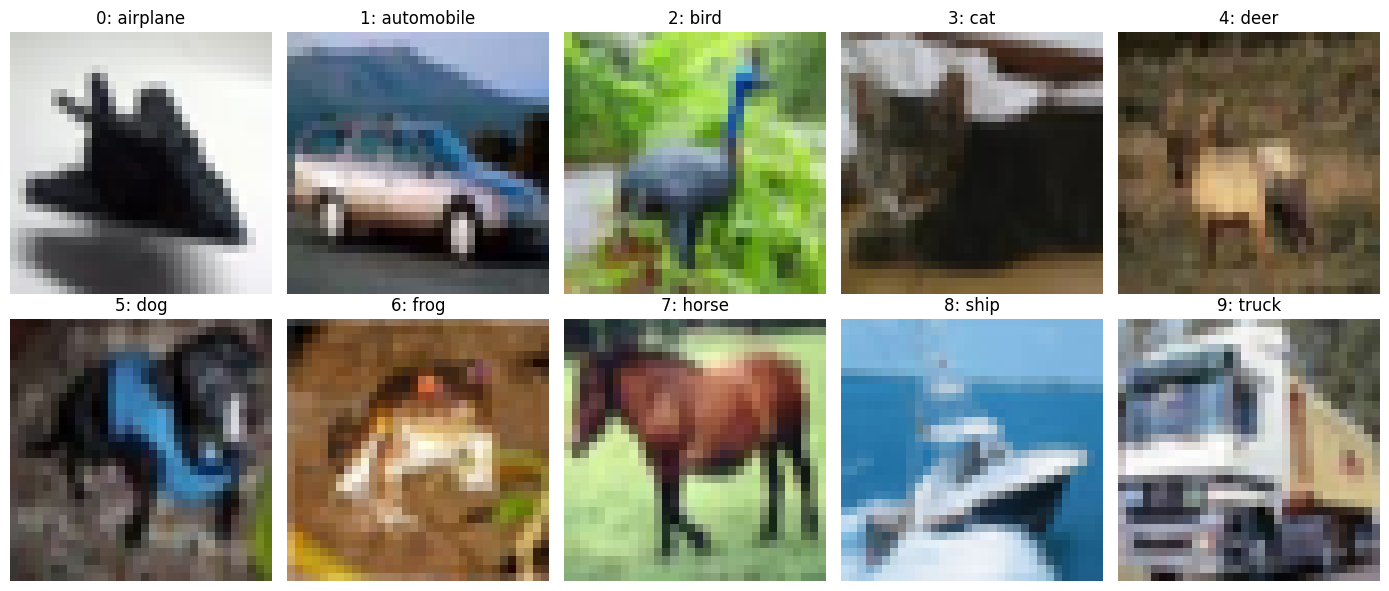

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


# Utility: read one CIFAR-10 batch/metadata pickle file from disk. From: https://www.cs.toronto.edu/~kriz/cifar.html
def unpickle(file_path):
    with open(file_path, "rb") as fo:
        batch = pickle.load(fo, encoding="bytes")
    return batch

# End-to-end loader for CIFAR-10 in the provided folder structure.
# Returns train/test images + labels, and human-readable class names.
def load_cifar10(data):
    # 1) Load class label names (airplane, automobile, etc.) from metadata.
    meta = unpickle(os.path.join(data, "batches.meta"))
    label_names = [name.decode("utf-8") for name in meta[b"label_names"]]

    # 2) Read and concatenate all 5 training batch files.
    train_images = []
    train_labels = []
    for i in range(1, 6):
        batch = unpickle(os.path.join(data, f"data_batch_{i}"))
        train_images.append(batch[b"data"])
        train_labels.extend(batch[b"labels"])

    # 3) Stack image rows into one array of shape (50000, 3072).
    X_train = np.vstack(train_images)
    y_train = np.array(train_labels, dtype=np.int64)

    return X_train, y_train, X_test, y_test, label_names

# Load the CIFAR-10 Dataset 
data = "cifar-10-batches-py"
X_train, y_train, X_test, y_test, label_names = load_cifar10(data)

# Quick shape sanity check to confirm successful parsing.
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print("Label names:", label_names)

# Visual inspection: show one example image from each class.
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for class_id, ax in enumerate(axes.ravel()):
    # Pick the first training sample for this class index.
    idx = np.where(y_train == class_id)[0][0]
    img = X_train[idx].reshape(3, 32, 32).transpose(1, 2, 0)  # (3072,) -> (32,32,3)
    ax.imshow(img)
    ax.set_title(f"{class_id}: {label_names[class_id]}")
    ax.axis("off")

plt.tight_layout()
plt.show()